# Event/background ROI QC metrics

This notebook estimates per-ROI background noise from dF/F samples that are not near detected events, then asks how large detected calcium events are relative to that background. It also includes the existing exponential-event / Gaussian-residual fit score so we can compare amplitude-based QC with event-shape QC.

The Allen visual behavior optical physiology documentation describes the released ophys products as including baseline-corrected dF/F traces and detected events from an L0 event detection algorithm: [AllenSDK visual behavior optical physiology docs](https://allensdk.readthedocs.io/en/latest/visual_behavior_optical_physiology.html).

## Analysis settings

`SESSION_DIR` should point to a materialized session cache. On PACE this should usually live in scratch or project storage, not home. The default below uses the cached example session we have already materialized.

Timing defaults are intentionally parameters, not fixed biological truths. The OpenScope hardware overview lists mesoscope temporal resolution as approximately `90 ms`, so sub-second windows are only sampled by a small number of frames: [OpenScope hardware overview](https://allenneuraldynamics.github.io/openscope-community-predictive-processing/hardware-overview/).

- `BACKGROUND_EXCLUDE_PRE_S = 0.5`: remove the half-second before each detected event from background estimation.
- `BACKGROUND_EXCLUDE_POST_S = 2.0`: remove two seconds after each detected event, covering most event rise and early decay for a GCaMP-like mesoscope transient.
- `MERGE_WITHIN_S = 0.5`: detected event onsets closer than this are treated as one calcium-transient cluster for amplitude measurement.
- `PEAK_SEARCH_POST_S = 2.0`: search for the dF/F peak up to two seconds after the midpoint of a merged cluster.

The `2.0 s` post-event window is a first-pass QC choice. Allen-related L0 event extraction work used a fixed transient half-time of `315 ms`, and GCaMP6f literature reports faster isolated-spike kinetics but longer observed calcium events when activity accumulates: [de Vries et al. / Allen L0 event extraction discussion](https://pmc.ncbi.nlm.nih.gov/articles/PMC8285106/), [GCaMP6f kinetics review](https://pmc.ncbi.nlm.nih.gov/articles/PMC4852807/), [GCaMP6f population transients discussion](https://pmc.ncbi.nlm.nih.gov/articles/PMC6593119/).

For visual cortex mesoscope data, these are reasonable first-pass QC windows. The correct values should be checked from the event-triggered average plots below: if peaks are still rising at the right edge, increase the post window; if unrelated activity is being merged, decrease it.

In [13]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mesoscope_snr import (
    calculate_roi_snr_metrics,
    event_cluster_amplitude_table,
    event_composition_kmeans,
    event_composition_labels,
    long_event_window_flags,
    roi_event_composition_from_cluster_table,
    _event_onsets,
    _merged_event_clusters,
)

SESSION_DIR = Path("/storage/scratch1/3/grubin6/openscope_ophys_qc_materialized/multiplane-ophys_839909_2026-02-20_12-53-27")
PLANES = "all"  # "all" or a list such as ["VISp_0", "VISp_1"]
OUTPUT_DIR = REPO_ROOT / "outputs" / "background_event_qc"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_FRAMES = None
EVENT_THRESHOLD = 0.0
BACKGROUND_EXCLUDE_PRE_S = 0.5
BACKGROUND_EXCLUDE_POST_S = 2.0
MERGE_WITHIN_S = 0.5
LOCAL_BASELINE_PRE_S = 0.5
PEAK_SEARCH_POST_S = 2.0
MIN_EVENTS_FOR_DISTRIBUTION_FIT = 20

LOW_EVENT_SD = 2.0
HIGH_EVENT_SD = 4.0

## Metric definitions

For each ROI, the notebook first finds detected event onsets from Allen/OASIS-style events. In Allen visual behavior ophys data, these event traces are produced by an L0 event detection algorithm and are distributed alongside dF/F: [AllenSDK visual behavior optical physiology docs](https://allensdk.readthedocs.io/en/latest/visual_behavior_optical_physiology.html).

The notebook removes a window around those onsets from the dF/F trace and treats the remaining samples as background. The core background estimate is a robust MAD-based standard deviation:

$$
\sigma_{background} = 1.4826 \cdot median(|x_{background} - median(x_{background})|)
$$

Detected event onsets that occur close together are merged into one event cluster. The event time is the midpoint between the first and last onset in that cluster. For each cluster, the event amplitude is the post-midpoint dF/F peak minus a local pre-midpoint baseline:

$$
A_{event} = max(\Delta F/F_{midpoint:midpoint+2s}) - median(\Delta F/F_{midpoint-0.5s:midpoint})
$$

The main amplitude score is expressed in background-noise units:

$$
Z_{event} = \frac{A_{event}}{\sigma_{background}}
$$

This gives interpretable bins: events below `2 SD`, events between `2-4 SD`, and events above `4 SD` relative to that ROI's own background. The `2x noise floor` idea is also consistent with Allen-related L0 event extraction work that adjusted regularization so the smallest detected events were at least 200% of the noise floor: [Allen-related L0 event extraction methods](https://pmc.ncbi.nlm.nih.gov/articles/PMC8285106/).

In [14]:
def available_planes(session_dir):
    planes = sorted([p.name for p in session_dir.iterdir() if p.is_dir() and (p / "dff.npy").exists()])
    return planes


def load_cached_plane(session_dir, plane, max_frames=None):
    plane_dir = session_dir / plane
    dff = np.load(plane_dir / "dff.npy", mmap_mode="r")
    events_path = plane_dir / "events.npy"
    events = np.load(events_path, mmap_mode="r") if events_path.exists() else None
    timestamps_path = plane_dir / "dff_timestamps.npy"
    timestamps = np.load(timestamps_path, mmap_mode="r") if timestamps_path.exists() else None

    dff_frames_rois = dff if dff.shape[0] >= dff.shape[1] else dff.T
    n_frames = dff_frames_rois.shape[0] if max_frames is None else min(max_frames, dff_frames_rois.shape[0])
    dff_frames_rois = np.asarray(dff_frames_rois[:n_frames], dtype=np.float32)

    events_frames_rois = None
    if events is not None:
        events_frames_rois = events if events.shape[0] >= events.shape[1] else events.T
        events_frames_rois = np.asarray(events_frames_rois[:n_frames, : dff_frames_rois.shape[1]], dtype=np.float32)

    if timestamps is None:
        timestamps = np.arange(n_frames, dtype=float)
    else:
        timestamps = np.asarray(timestamps[:n_frames], dtype=float)
    return dff_frames_rois, events_frames_rois, timestamps


def selected_planes(session_dir, planes):
    all_planes = available_planes(session_dir)
    if planes == "all":
        return all_planes
    return [p for p in planes if p in all_planes]

planes_to_run = selected_planes(SESSION_DIR, PLANES)
planes_to_run

['VISl_4',
 'VISl_5',
 'VISl_6',
 'VISl_7',
 'VISp_0',
 'VISp_1',
 'VISp_2',
 'VISp_3']

## Compute compact ROI metrics

This cell stores one row per ROI. It does **not** save full dF/F traces. The saved table keeps enough identity information (`session_dir`, `plane`, `roi_index`) to retrieve a trace later when a plot or viewer needs it.

In [15]:
all_metrics = []
timing_rows = []
start_all = time.perf_counter()

for plane in planes_to_run:
    t0 = time.perf_counter()
    dff, events, timestamps = load_cached_plane(SESSION_DIR, plane, max_frames=MAX_FRAMES)
    metrics = calculate_roi_snr_metrics(
        dff,
        timestamps=timestamps,
        events=events,
        event_threshold=EVENT_THRESHOLD,
        kernel_pre_s=BACKGROUND_EXCLUDE_PRE_S,
        kernel_post_s=BACKGROUND_EXCLUDE_POST_S,
        min_events_for_distribution_fit=MIN_EVENTS_FOR_DISTRIBUTION_FIT,
        background_event_merge_within_s=MERGE_WITHIN_S,
        background_event_local_baseline_pre_s=LOCAL_BASELINE_PRE_S,
        background_event_peak_search_post_s=PEAK_SEARCH_POST_S,
        background_event_low_sd=LOW_EVENT_SD,
        background_event_high_sd=HIGH_EVENT_SD,
    )
    metrics.insert(0, "session_dir", str(SESSION_DIR))
    metrics.insert(1, "session", SESSION_DIR.name)
    metrics.insert(2, "plane", plane)
    all_metrics.append(metrics)
    timing_rows.append({
        "plane": plane,
        "n_rois": dff.shape[1],
        "n_frames": dff.shape[0],
        "has_events": events is not None,
        "elapsed_s": time.perf_counter() - t0,
    })

roi_metrics = pd.concat(all_metrics, ignore_index=True)
timing = pd.DataFrame(timing_rows)
metrics_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_background_event_roi_metrics.csv"
timing_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_background_event_timing.csv"
roi_metrics.to_csv(metrics_csv, index=False)
timing.to_csv(timing_csv, index=False)

print(f"Saved {len(roi_metrics):,} ROI rows to {metrics_csv}")
print(f"Elapsed total: {time.perf_counter() - start_all:.1f} s")
display(timing)
display(roi_metrics.head())

Saved 1,810 ROI rows to /storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/background_event_qc/multiplane-ophys_839909_2026-02-20_12-53-27_background_event_roi_metrics.csv
Elapsed total: 75.1 s


,plane,n_rois,n_frames,has_events,elapsed_s
0,VISl_4,351,10000,True,13.269086
1,VISl_5,235,10000,True,12.680594
2,VISl_6,76,10000,True,2.520400
3,VISl_7,288,10000,True,10.965104
4,VISp_0,345,10000,True,12.965397
5,VISp_1,230,10000,True,12.074670
6,VISp_2,84,10000,True,2.574403
7,VISp_3,201,10000,True,7.764971


,session_dir,session,plane,roi_index,n_timepoints,n_finite_timepoints,fraction_nan,robust_event_snr,robust_event_signal_amp,robust_event_noise_sd,...,background_event_fraction_2_4sd,background_event_fraction_gt_4sd,background_event_count_ge_2sd,background_event_rate_ge_2sd_hz,event_exp_gauss_fit_score,event_exponential_scale,event_exponential_ks_stat,event_exponential_ks_pvalue,event_model_residual_gaussian_ks_stat,event_model_residual_gaussian_ks_pvalue
0,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,0,10000,10000,0.0,1.936100,0.205288,0.106032,...,0.390335,0.486989,236,0.252648,0.779465,0.058654,0.078798,0.013656,0.362271,3.482927e-47
1,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,1,10000,10000,0.0,3.402822,0.215190,0.063239,...,0.053097,0.946903,226,0.241943,0.796665,0.151770,0.041993,0.600191,0.364677,3.025556e-39
2,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,2,10000,10000,0.0,2.244994,0.189742,0.084518,...,0.557377,0.251366,444,0.475321,0.830677,0.036934,0.034224,0.088106,0.304422,2.663777e-109
3,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,3,10000,10000,0.0,2.059020,0.144355,0.070108,...,0.709150,0.212418,282,0.301893,0.827100,0.022168,0.024092,0.957468,0.321708,1.822554e-40
4,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,4,10000,10000,0.0,2.203539,0.699469,0.317430,...,0.530303,0.454545,65,0.069585,0.855380,0.108033,0.053366,0.954126,0.235874,9.656974e-05


## Merged-event cluster diagnostics

This checks whether the merge rule is creating clusters that are too long to interpret as one calcium response. With the current midpoint method, each amplitude is measured from `0.5 s` before the cluster midpoint to `2.0 s` after the cluster midpoint. Long cluster spans are still worth flagging because they indicate sustained event-detection periods rather than isolated transients.

The rationale is that mesoscope sampling is moderate, approximately `90 ms`, while GCaMP6f responses to isolated spikes can be much faster and accumulated responses can last around a second or more. Therefore, clusters of several seconds should be treated as sustained activity/artifact candidates rather than a single simple transient: [OpenScope hardware overview](https://allenneuraldynamics.github.io/openscope-community-predictive-processing/hardware-overview/), [GCaMP6f kinetics review](https://pmc.ncbi.nlm.nih.gov/articles/PMC4852807/), [GCaMP6f population transients discussion](https://pmc.ncbi.nlm.nih.gov/articles/PMC6593119/).

,n_clusters,median_cluster_span_s,p95_cluster_span_s,max_cluster_span_s,max_raw_onsets_in_cluster
plane,,,,,
VISl_4,80589,0.0,0.74736,5.51178,21
VISl_5,102607,0.0,0.93420,8.50122,30
VISl_6,13681,0.0,0.74736,5.23152,17
VISl_7,71173,0.0,0.74736,6.63282,21
VISp_0,81836,0.0,0.65394,4.48416,17
VISp_1,97151,0.0,0.93420,7.38018,28
VISp_2,13055,0.0,0.74736,4.95126,17
VISp_3,51226,0.0,0.74736,8.31438,31


,plane,roi_index,first_onset_frame,last_onset_frame,midpoint_frame,first_onset_s,last_onset_s,midpoint_s,cluster_span_s,evaluation_start_s,evaluation_end_s,raw_onsets_in_cluster
95165,VISl_5,33,4073,4164,4118,418.72970,427.23096,422.93362,8.50122,422.46652,424.89545,30
471497,VISp_3,49,4289,4378,4334,438.88516,447.19959,443.08909,8.31438,442.62198,445.05092,31
396288,VISp_1,108,4275,4354,4314,437.55392,444.93414,441.19732,7.38018,440.73022,443.15915,28
175710,VISl_5,215,4085,4159,4122,419.85075,426.76386,423.30730,6.91308,422.84020,425.26913,24
214184,VISl_7,71,4740,4811,4776,481.06453,487.69739,484.42767,6.63282,483.96057,486.38951,21
115210,VISl_5,76,4216,4286,4251,432.08883,438.62826,435.35854,6.53940,434.89144,437.32037,20
155837,VISl_5,170,4082,4150,4116,419.57049,425.92308,422.74678,6.35256,422.27968,424.70861,22
471494,VISp_3,49,4192,4260,4226,429.82338,436.17597,432.99968,6.35256,432.53257,434.96150,22
81440,VISl_5,3,76,144,110,45.33632,51.68821,48.51226,6.35256,48.04520,50.47387,19
410709,VISp_1,142,6488,6554,6521,644.29391,650.45969,647.37680,6.16572,646.90970,649.33864,22


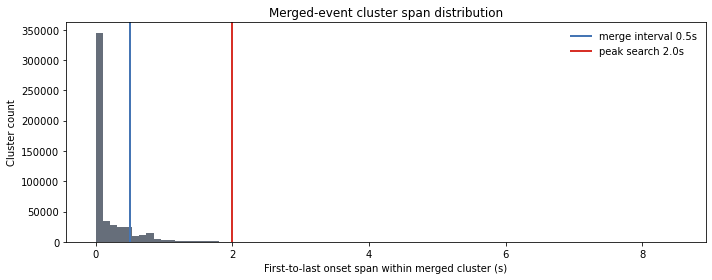

In [16]:
def summarize_event_clusters(session_dir, planes, max_frames=None, event_threshold=0.0, merge_within_s=0.5):
    rows = []
    for plane in planes:
        dff, events, timestamps = load_cached_plane(session_dir, plane, max_frames=max_frames)
        if events is None:
            continue
        frame_rate = 1 / np.nanmedian(np.diff(timestamps))
        for roi_index in range(events.shape[1]):
            onsets = _event_onsets(events[:, roi_index], event_threshold)
            clusters = _merged_event_clusters(onsets, frame_rate, merge_within_s)
            for first, last, raw_count in clusters:
                midpoint = int(round((first + last) / 2))
                rows.append({
                    "plane": plane,
                    "roi_index": roi_index,
                    "first_onset_frame": first,
                    "last_onset_frame": last,
                    "midpoint_frame": midpoint,
                    "first_onset_s": timestamps[first],
                    "last_onset_s": timestamps[last],
                    "midpoint_s": timestamps[midpoint],
                    "cluster_span_s": (last - first) / frame_rate,
                    "evaluation_start_s": timestamps[max(0, midpoint - int(round(LOCAL_BASELINE_PRE_S * frame_rate)))],
                    "evaluation_end_s": timestamps[min(len(timestamps) - 1, midpoint + int(round(PEAK_SEARCH_POST_S * frame_rate)))],
                    "raw_onsets_in_cluster": raw_count,
                })
    return pd.DataFrame(rows)

cluster_summary = summarize_event_clusters(
    SESSION_DIR,
    planes_to_run,
    max_frames=MAX_FRAMES,
    event_threshold=EVENT_THRESHOLD,
    merge_within_s=MERGE_WITHIN_S,
)

if cluster_summary.empty:
    print("No event clusters found.")
else:
    by_plane = cluster_summary.groupby("plane").agg(
        n_clusters=("cluster_span_s", "size"),
        median_cluster_span_s=("cluster_span_s", "median"),
        p95_cluster_span_s=("cluster_span_s", lambda x: np.nanpercentile(x, 95)),
        max_cluster_span_s=("cluster_span_s", "max"),
        max_raw_onsets_in_cluster=("raw_onsets_in_cluster", "max"),
    )
    display(by_plane)
    display(cluster_summary.sort_values("cluster_span_s", ascending=False).head(20))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(cluster_summary["cluster_span_s"], bins=80, color="#4b5563", alpha=0.85)
    ax.axvline(MERGE_WITHIN_S, color="#4575b4", lw=2, label=f"merge interval {MERGE_WITHIN_S}s")
    ax.axvline(PEAK_SEARCH_POST_S, color="#d73027", lw=2, label=f"peak search {PEAK_SEARCH_POST_S}s")
    ax.set_xlabel("First-to-last onset span within merged cluster (s)")
    ax.set_ylabel("Cluster count")
    ax.set_title("Merged-event cluster span distribution")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


## Metric distributions

These plots show the key background/event metrics across ROIs. The most useful first-pass columns are usually:

- `background_noise_sd`: baseline noise from non-event dF/F samples.
- `background_event_median_amp_noise_units`: median merged-event amplitude in background SD units.
- `background_event_p95_amp_noise_units`: upper-tail merged-event amplitude in background SD units.
- `background_event_fraction_lt_2sd`, `background_event_fraction_2_4sd`, `background_event_fraction_gt_4sd`: where detected events fall relative to background.
- `event_exp_gauss_fit_score`: whether extracted event amplitudes look exponential and residual error looks Gaussian. Higher is better.

The event-fit score is complementary to amplitude-over-background metrics: it asks whether the detected-event amplitudes and residuals have distributional behavior consistent with the assumptions behind deconvolution/event extraction rather than only asking whether events are large. Allen-related work describes using L0 event extraction before response metrics, and Allen docs describe these released event traces as part of the ophys product: [Allen-related L0 event extraction methods](https://pmc.ncbi.nlm.nih.gov/articles/PMC8285106/), [AllenSDK visual behavior optical physiology docs](https://allensdk.readthedocs.io/en/latest/visual_behavior_optical_physiology.html).

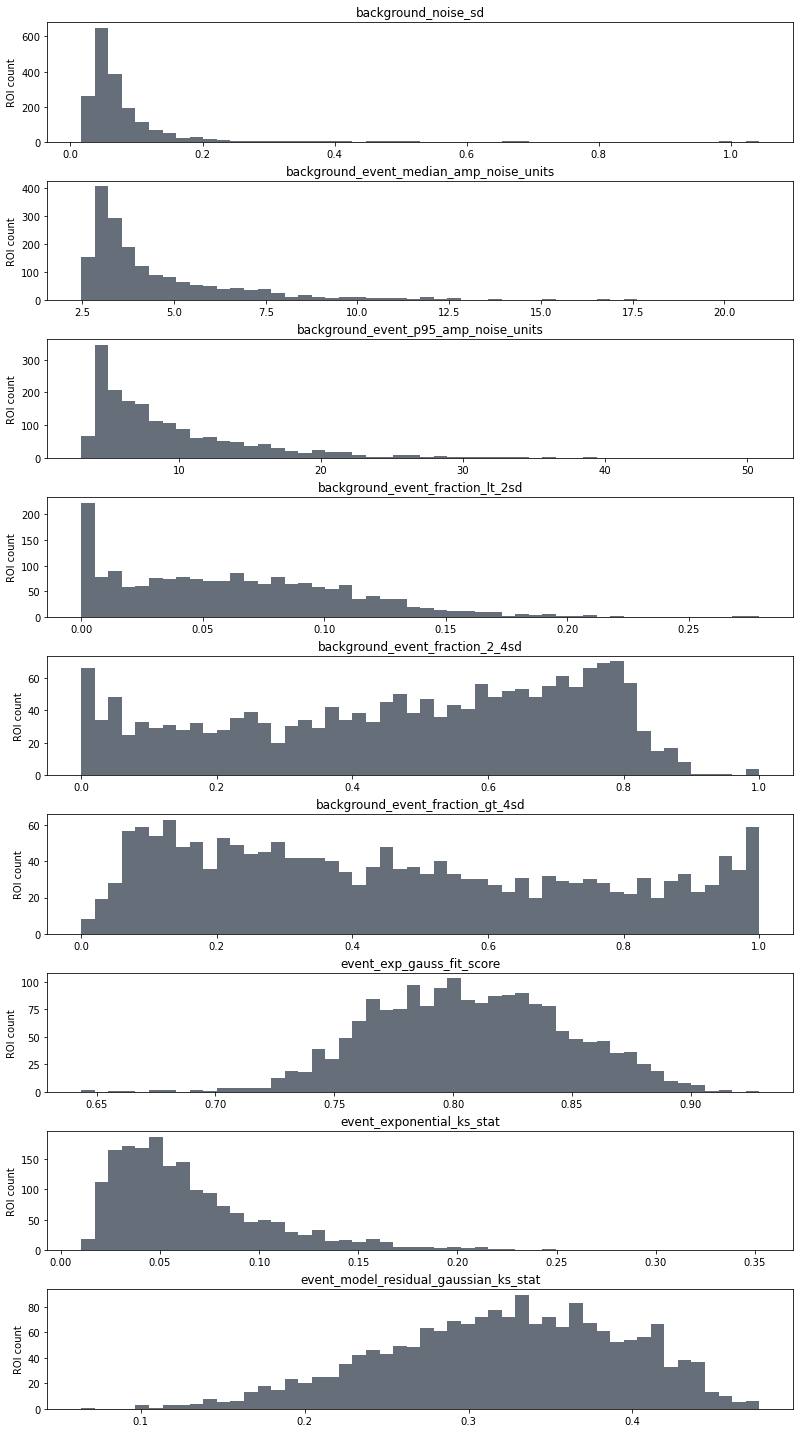

In [17]:
plot_cols = [
    "background_noise_sd",
    "background_event_median_amp_noise_units",
    "background_event_p95_amp_noise_units",
    "background_event_fraction_lt_2sd",
    "background_event_fraction_2_4sd",
    "background_event_fraction_gt_4sd",
    "event_exp_gauss_fit_score",
    "event_exponential_ks_stat",
    "event_model_residual_gaussian_ks_stat",
]
plot_cols = [c for c in plot_cols if c in roi_metrics.columns]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(11, 2.2 * len(plot_cols)), constrained_layout=True)
if len(plot_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, plot_cols):
    vals = pd.to_numeric(roi_metrics[col], errors="coerce").dropna()
    ax.hist(vals, bins=50, color="#4b5563", alpha=0.85)
    ax.set_title(col)
    ax.set_ylabel("ROI count")
plt.show()

## Event amplitude bands

This summarizes the collaborator's proposed bins directly. For a clean ROI, a useful event detector should produce many merged events above background, not mostly events inside the background distribution.

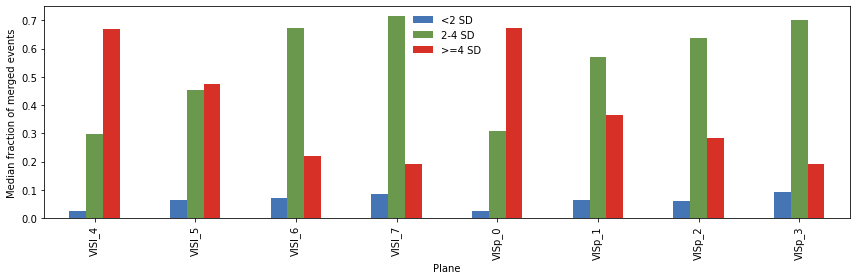

,background_event_fraction_lt_2sd,background_event_fraction_2_4sd,background_event_fraction_gt_4sd
plane,,,
VISl_4,0.024096,0.296919,0.669604
VISl_5,0.064909,0.454880,0.474645
VISl_6,0.071429,0.673139,0.218750
VISl_7,0.086920,0.713610,0.190273
VISp_0,0.025105,0.308271,0.671875
VISp_1,0.065940,0.569425,0.365310
VISp_2,0.061359,0.638407,0.284749
VISp_3,0.090909,0.700980,0.191667


In [18]:
band_cols = [
    "background_event_fraction_lt_2sd",
    "background_event_fraction_2_4sd",
    "background_event_fraction_gt_4sd",
]
summary = roi_metrics.groupby("plane")[band_cols].median(numeric_only=True)
ax = summary.plot(kind="bar", figsize=(12, 4), color=["#4575b4", "#6a994e", "#d73027"])
ax.set_ylabel("Median fraction of merged events")
ax.set_xlabel("Plane")
ax.legend(["<2 SD", "2-4 SD", ">=4 SD"], frameon=False)
plt.tight_layout()
plt.show()
summary

## ROI event-composition clustering

This section asks whether each ROI is primarily composed of one event-amplitude category: events below `2 SD`, events between `2-4 SD`, or events above `4 SD` relative to the ROI background. It reports both rule-based labels and an unsupervised k-means clustering on the three event-fraction columns.

The rule label is intentionally conservative. A ROI is called mostly one type only if the largest fraction is at least `55%` and exceeds the second-largest fraction by at least `15%`; otherwise it is labeled `mixed_or_ambiguous`. The cluster centroids are useful for deciding whether the data actually separate, or whether the event composition is mostly continuous.


In [ ]:
COMPOSITION_DOMINANCE_THRESHOLD = 0.55
COMPOSITION_AMBIGUITY_MARGIN = 0.15
LONG_CLUSTER_WARNING_S = 3.0
LONG_CLUSTER_SEVERE_S = 5.0
LONG_CLUSTER_EXTREME_S = 8.0

roi_metrics_labeled = event_composition_labels(
    roi_metrics,
    dominance_threshold=COMPOSITION_DOMINANCE_THRESHOLD,
    ambiguity_margin=COMPOSITION_AMBIGUITY_MARGIN,
)
roi_metrics_labeled, event_composition_centroids = event_composition_kmeans(
    roi_metrics_labeled,
    n_clusters=3,
)

# Merge long-window flags when the cluster diagnostics table has been computed.
if "cluster_summary" in globals() and not cluster_summary.empty:
    long_window_roi_flags = long_event_window_flags(
        cluster_summary,
        warning_span_s=LONG_CLUSTER_WARNING_S,
        severe_span_s=LONG_CLUSTER_SEVERE_S,
        extreme_span_s=LONG_CLUSTER_EXTREME_S,
    )
    roi_metrics_labeled = roi_metrics_labeled.merge(
        long_window_roi_flags,
        on=["plane", "roi_index"],
        how="left",
    )
else:
    long_window_roi_flags = pd.DataFrame()

flag_cols = [c for c in roi_metrics_labeled.columns if c.startswith("n_") and "long_event" in c]
for col in flag_cols:
    roi_metrics_labeled[col] = roi_metrics_labeled[col].fillna(0).astype(int)
for col in [c for c in roi_metrics_labeled.columns if c.startswith("has_") and "long_event" in c]:
    roi_metrics_labeled[col] = roi_metrics_labeled[col].where(roi_metrics_labeled[col].notna(), False).astype(bool)

labeled_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_background_event_roi_metrics_labeled.csv"
centroids_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_event_composition_cluster_centroids.csv"
roi_metrics_labeled.to_csv(labeled_csv, index=False)
event_composition_centroids.to_csv(centroids_csv, index=False)
print(f"Saved labeled ROI metrics to {labeled_csv}")
print(f"Saved event-composition centroids to {centroids_csv}")

display(roi_metrics_labeled["event_composition_label"].value_counts(dropna=False).rename("n_rois"))
display(event_composition_centroids)

cluster_counts = pd.crosstab(
    roi_metrics_labeled["event_composition_cluster"],
    roi_metrics_labeled["event_composition_label"],
    dropna=False,
)
display(cluster_counts)


## Event-composition visualization

The ternary-like scatter below projects the three event fractions into two dimensions. ROIs near the left/lower side are mostly `<2 SD` or `2-4 SD`; ROIs toward the upper right are enriched for `>=4 SD` events. If clusters overlap heavily rather than forming separated clouds, the metric is probably continuous and thresholds should be treated as tunable QC cutoffs rather than natural cell classes.


In [ ]:
composition_cols = [
    "background_event_fraction_lt_2sd",
    "background_event_fraction_2_4sd",
    "background_event_fraction_gt_4sd",
]
plot_df = roi_metrics_labeled.dropna(subset=composition_cols).copy()
# Simple barycentric projection for three fractions.
plot_df["composition_x"] = plot_df["background_event_fraction_2_4sd"] + 0.5 * plot_df["background_event_fraction_gt_4sd"]
plot_df["composition_y"] = (np.sqrt(3) / 2) * plot_df["background_event_fraction_gt_4sd"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for label, group in plot_df.groupby("event_composition_label"):
    axes[0].scatter(group["composition_x"], group["composition_y"], s=12, alpha=0.55, label=label)
axes[0].set_title("Rule-based event composition labels")
axes[0].set_xlabel("2-4 SD fraction + 0.5 * >=4 SD fraction")
axes[0].set_ylabel("projected >=4 SD fraction")
axes[0].legend(markerscale=2, frameon=False, fontsize=8)

for cluster, group in plot_df.groupby("event_composition_cluster"):
    axes[1].scatter(group["composition_x"], group["composition_y"], s=12, alpha=0.55, label=f"cluster {int(cluster)}")
axes[1].set_title("K-means clusters on event composition")
axes[1].set_xlabel("2-4 SD fraction + 0.5 * >=4 SD fraction")
axes[1].set_ylabel("projected >=4 SD fraction")
axes[1].legend(markerscale=2, frameon=False, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
label_order = roi_metrics_labeled["event_composition_label"].value_counts().index
roi_metrics_labeled["event_composition_label"].value_counts().loc[label_order].plot(kind="bar", ax=ax, color="#4b5563")
ax.set_ylabel("ROI count")
ax.set_title("ROI counts by conservative event-composition label")
plt.tight_layout()
plt.show()


## 3D event composition excluding long clusters

This version treats merged event clusters with span `>=3 s` as a separate `long_gt_3s` category. Those long clusters are **not** included when calculating the three event-type percentages used for ROI clustering. The 3D coordinates are therefore:

- x: fraction of non-long events `<2 SD`
- y: fraction of non-long events `2-4 SD`
- z: fraction of non-long events `>=4 SD`

Point color shows k-means membership based only on those three non-long fractions. A black marker edge means the ROI had at least one `>=3 s` event cluster, so it should be inspected separately even though those long events were excluded from the composition used for clustering.


In [ ]:
LONG_EVENT_CATEGORY_SPAN_S = 3.0

cluster_amp_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_event_clusters_with_amplitude_classes.csv"
nonlong_composition_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_nonlong_event_composition_by_roi.csv"
nonlong_annotated_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_roi_metrics_with_nonlong_event_composition.csv"
nonlong_centroids_csv = OUTPUT_DIR / f"{SESSION_DIR.name}_nonlong_event_composition_centroids.csv"
composition_3d_png = OUTPUT_DIR / f"{SESSION_DIR.name}_nonlong_event_composition_3d.png"

if cluster_amp_csv.exists() and nonlong_composition_csv.exists() and nonlong_centroids_csv.exists():
    cluster_amp_table = pd.read_csv(cluster_amp_csv)
    nonlong_composition = pd.read_csv(nonlong_composition_csv)
    nonlong_centroids = pd.read_csv(nonlong_centroids_csv)
else:
    cluster_amp_tables = []
    for plane in planes_to_run:
        dff, events, timestamps = load_cached_plane(SESSION_DIR, plane, max_frames=MAX_FRAMES)
        plane_metrics = roi_metrics_labeled.loc[roi_metrics_labeled["plane"].astype(str) == str(plane)] if "roi_metrics_labeled" in globals() else roi_metrics.loc[roi_metrics["plane"].astype(str) == str(plane)]
        table = event_cluster_amplitude_table(
            dff,
            events,
            timestamps,
            roi_metrics=plane_metrics,
            plane=plane,
            event_threshold=EVENT_THRESHOLD,
            merge_within_s=MERGE_WITHIN_S,
            local_baseline_pre_s=LOCAL_BASELINE_PRE_S,
            peak_search_post_s=PEAK_SEARCH_POST_S,
            long_span_s=LONG_EVENT_CATEGORY_SPAN_S,
        )
        table.insert(0, "session", SESSION_DIR.name)
        cluster_amp_tables.append(table)
    cluster_amp_table = pd.concat(cluster_amp_tables, ignore_index=True)
    nonlong_composition = roi_event_composition_from_cluster_table(
        cluster_amp_table,
        group_cols=("plane", "roi_index"),
    )
    nonlong_composition.insert(0, "session", SESSION_DIR.name)

    kmeans_input = nonlong_composition.rename(columns={
        "nonlong_event_fraction_lt_2sd": "background_event_fraction_lt_2sd",
        "nonlong_event_fraction_2_4sd": "background_event_fraction_2_4sd",
        "nonlong_event_fraction_gt_4sd": "background_event_fraction_gt_4sd",
    })
    kmeans_labeled, nonlong_centroids = event_composition_kmeans(kmeans_input, n_clusters=3)
    nonlong_composition["nonlong_event_composition_cluster"] = kmeans_labeled["event_composition_cluster"]
    nonlong_centroids = nonlong_centroids.rename(columns={
        "event_composition_cluster": "nonlong_event_composition_cluster",
        "centroid_fraction_lt_2sd": "centroid_nonlong_fraction_lt_2sd",
        "centroid_fraction_2_4sd": "centroid_nonlong_fraction_2_4sd",
        "centroid_fraction_gt_4sd": "centroid_nonlong_fraction_gt_4sd",
    })
    cluster_amp_table.to_csv(cluster_amp_csv, index=False)
    nonlong_composition.to_csv(nonlong_composition_csv, index=False)
    nonlong_centroids.to_csv(nonlong_centroids_csv, index=False)

roi_metrics_nonlong = roi_metrics_labeled.merge(
    nonlong_composition,
    on=["session", "plane", "roi_index"],
    how="left",
    suffixes=("", "_nonlong"),
) if "roi_metrics_labeled" in globals() else roi_metrics.merge(
    nonlong_composition,
    on=["session", "plane", "roi_index"],
    how="left",
    suffixes=("", "_nonlong"),
)
roi_metrics_nonlong.to_csv(nonlong_annotated_csv, index=False)

print("Event cluster type counts with >=3 s clusters separated:")
display(cluster_amp_table["event_type"].value_counts().rename("n_clusters"))
print("Non-long composition centroids:")
display(nonlong_centroids)
print(f"ROIs with at least one >=3 s cluster: {int(nonlong_composition['has_long_gt_3s_event_cluster'].sum())} / {len(nonlong_composition)}")


## 3D event-composition plot

The plot is saved to `outputs/background_event_qc`. Because the three plotted fractions sum to one after long events are excluded, the cloud should lie near a simplex surface. If the colored clusters form a smooth gradient rather than separated islands, that argues for treating the metric as continuous rather than forcing hard event-type classes.


In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plot_df = nonlong_composition.dropna(subset=[
    "nonlong_event_fraction_lt_2sd",
    "nonlong_event_fraction_2_4sd",
    "nonlong_event_fraction_gt_4sd",
    "nonlong_event_composition_cluster",
]).copy()
cluster_colors = {0: "#4575b4", 1: "#6a994e", 2: "#d73027"}

fig = plt.figure(figsize=(10.5, 8.5))
ax = fig.add_subplot(111, projection="3d")
for cluster, group in plot_df.groupby("nonlong_event_composition_cluster"):
    cluster_id = int(cluster)
    edgecolors = np.where(group["has_long_gt_3s_event_cluster"], "#111827", "none")
    linewidths = np.where(group["has_long_gt_3s_event_cluster"], 0.8, 0.0)
    ax.scatter(
        group["nonlong_event_fraction_lt_2sd"],
        group["nonlong_event_fraction_2_4sd"],
        group["nonlong_event_fraction_gt_4sd"],
        s=28,
        alpha=0.72,
        color=cluster_colors.get(cluster_id, "#64748b"),
        edgecolors=edgecolors,
        linewidths=linewidths,
        label=f"cluster {cluster_id} (n={len(group)})",
    )
ax.set_xlabel("<2 SD fraction, non-long events")
ax.set_ylabel("2-4 SD fraction, non-long events")
ax.set_zlabel(">=4 SD fraction, non-long events")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.view_init(elev=24, azim=42)
ax.set_title(
    "ROI event composition excluding >=3 s event clusters
"
    f"black outline: ROI has >=1 long cluster (n={int(plot_df['has_long_gt_3s_event_cluster'].sum())})"
)
ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98), frameon=False)
fig.tight_layout()
fig.savefig(composition_3d_png, dpi=180)
plt.show()
print(composition_3d_png)


## Interactive 3D event-composition viewer

This standalone HTML viewer embeds the ROI event-composition coordinates and the session dF/F traces. Drag the 3D plot to rotate, use the wheel to zoom, and click an ROI point to inspect that ROI trace. The plotted axes are the percentages of non-long event clusters in `<2 SD`, `2-4 SD`, and `>=4 SD` categories; event clusters spanning `>=3 s` are excluded from those percentages and marked separately in the viewer.


In [ ]:
from IPython.display import HTML, IFrame, display

interactive_3d_html = REPO_ROOT / "outputs" / "html_viewers" / "multiplane-ophys_839909_event_composition_3d.html"
notebook_relative_3d_html = "../" + str(interactive_3d_html.relative_to(REPO_ROOT))

if not interactive_3d_html.exists():
    raise FileNotFoundError(
        f"Interactive viewer not found: {interactive_3d_html}. "
        "Run scripts/create_event_composition_3d_html.py after computing event-composition tables."
    )

display(HTML(f'<p><a href="{notebook_relative_3d_html}" target="_blank">Open interactive 3D event-composition viewer in a new tab</a></p>'))
display(IFrame(src=notebook_relative_3d_html, width="100%", height=920))


## Long event-window flags for trace inspection

These flags identify ROIs with merged-event clusters that are probably too long to treat as isolated calcium transients. The defaults are `>=3 s` warning, `>=5 s` severe, and `>=8 s` extreme. Use the table below to choose ROIs for direct trace inspection.


In [ ]:
long_flag_cols = [
    "has_warning_long_event_cluster",
    "has_severe_long_event_cluster",
    "has_extreme_long_event_cluster",
    "n_warning_long_event_clusters",
    "n_severe_long_event_clusters",
    "n_extreme_long_event_clusters",
    "max_event_cluster_span_s",
    "p95_event_cluster_span_s",
    "max_raw_onsets_in_cluster",
]
long_flag_cols = [c for c in long_flag_cols if c in roi_metrics_labeled.columns]

if not long_flag_cols:
    print("Run the merged-event cluster diagnostics cell first to create cluster_summary.")
else:
    flag_summary = {
        "warning >= 3s": int(roi_metrics_labeled["has_warning_long_event_cluster"].sum()),
        "severe >= 5s": int(roi_metrics_labeled["has_severe_long_event_cluster"].sum()),
        "extreme >= 8s": int(roi_metrics_labeled["has_extreme_long_event_cluster"].sum()),
    }
    display(pd.Series(flag_summary, name="n_rois"))
    inspect_cols = [
        "session", "plane", "roi_index", "event_composition_label", "event_composition_cluster",
        "background_event_fraction_lt_2sd", "background_event_fraction_2_4sd", "background_event_fraction_gt_4sd",
        *long_flag_cols,
    ]
    inspect_cols = [c for c in inspect_cols if c in roi_metrics_labeled.columns]
    long_event_rois = roi_metrics_labeled.loc[
        roi_metrics_labeled.get("has_warning_long_event_cluster", False)
    ].sort_values("max_event_cluster_span_s", ascending=False)
    display(long_event_rois[inspect_cols].head(30))


## Compare amplitude-based QC with event-fit QC

This scatter asks whether ROIs with large events relative to their background also have event amplitudes that match the exponential/Gaussian model. Disagreement cases are probably the most informative traces to inspect.

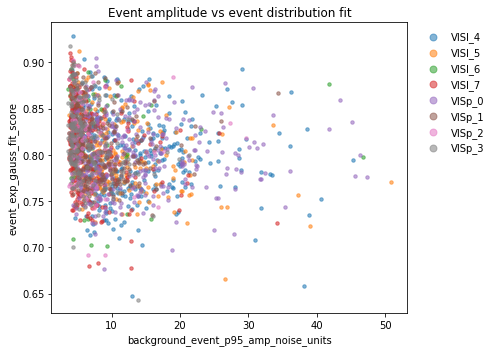

In [19]:
x_col = "background_event_p95_amp_noise_units"
y_col = "event_exp_gauss_fit_score"
fig, ax = plt.subplots(figsize=(7, 5))
for plane, group in roi_metrics.groupby("plane"):
    ax.scatter(group[x_col], group[y_col], s=12, alpha=0.55, label=plane)
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_title("Event amplitude vs event distribution fit")
ax.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## Trace examples by metric bin

This cell bins ROIs into low, medium, and high values for one metric, then plots randomly sampled dF/F traces from each bin. If a metric is useful, the high bin should have clearer calcium-like transients and the low bin should look worse by visual inspection.

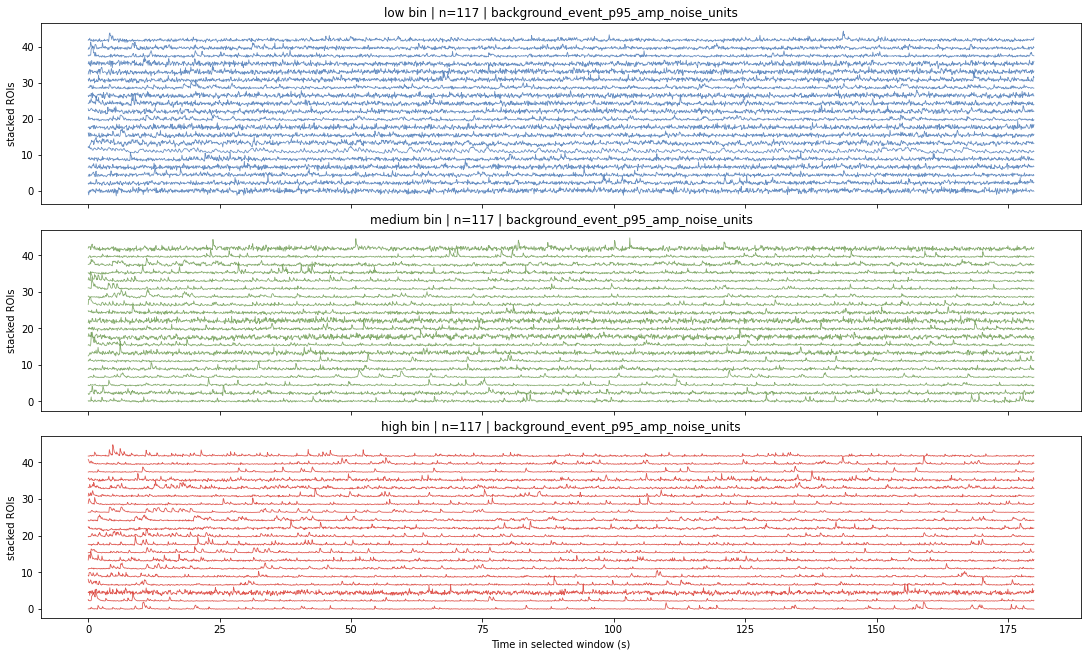

In [20]:
METRIC_FOR_TRACE_BINS = "background_event_p95_amp_noise_units"
PLANE_FOR_TRACE_EXAMPLES = planes_to_run[0]
N_RANDOM_PER_BIN = 20
TRACE_START_S = 0
TRACE_END_S = 180
RANDOM_SEED = 3

rng = np.random.default_rng(RANDOM_SEED)
plane_df = roi_metrics.query("plane == @PLANE_FOR_TRACE_EXAMPLES").copy()
vals = pd.to_numeric(plane_df[METRIC_FOR_TRACE_BINS], errors="coerce")
q1, q2 = vals.quantile([1/3, 2/3])
plane_df["metric_bin"] = pd.cut(vals, [-np.inf, q1, q2, np.inf], labels=["low", "medium", "high"])

dff, events, timestamps = load_cached_plane(SESSION_DIR, PLANE_FOR_TRACE_EXAMPLES, max_frames=MAX_FRAMES)
frame_rate = 1 / np.nanmedian(np.diff(timestamps))
f0 = max(0, int(round(TRACE_START_S * frame_rate)))
f1 = min(dff.shape[0], int(round(TRACE_END_S * frame_rate)))
time_axis = timestamps[f0:f1] - timestamps[f0]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True, constrained_layout=True)
colors = {"low":"#4575b4", "medium":"#6a994e", "high":"#d73027"}
for ax, bin_name in zip(axes, ["low", "medium", "high"]):
    rows = plane_df.loc[plane_df["metric_bin"] == bin_name]
    if rows.empty:
        ax.set_title(f"{bin_name}: no ROIs")
        continue
    sample = rows.sample(min(N_RANDOM_PER_BIN, len(rows)), random_state=RANDOM_SEED)
    offset = 0.0
    for _, row in sample.iterrows():
        trace = dff[f0:f1, int(row.roi_index)].astype(float)
        trace = trace - np.nanmedian(trace)
        scale = np.nanpercentile(np.abs(trace), 99)
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0
        ax.plot(time_axis, trace / scale + offset, color=colors[bin_name], lw=0.8, alpha=0.8)
        offset += 2.2
    ax.set_title(f"{bin_name} bin | n={len(rows)} | {METRIC_FOR_TRACE_BINS}")
    ax.set_ylabel("stacked ROIs")
axes[-1].set_xlabel("Time in selected window (s)")
plt.show()

## Event-triggered average by event-amplitude bin

This checks whether ROIs in each metric bin have the expected calcium-transient shape around detected event onsets. The default window is `0.5 s` before to `2 s` after event onset.

These windows should be interpreted relative to the acquisition rate and indicator kinetics. OpenScope mesoscope data are approximately `90 ms` temporal resolution, GCaMP6f isolated-spike decay can be on the order of hundreds of milliseconds, and accumulated calcium responses can last around a second or longer: [OpenScope hardware overview](https://allenneuraldynamics.github.io/openscope-community-predictive-processing/hardware-overview/), [GCaMP6f kinetics review](https://pmc.ncbi.nlm.nih.gov/articles/PMC4852807/), [GCaMP6f population transients discussion](https://pmc.ncbi.nlm.nih.gov/articles/PMC6593119/).

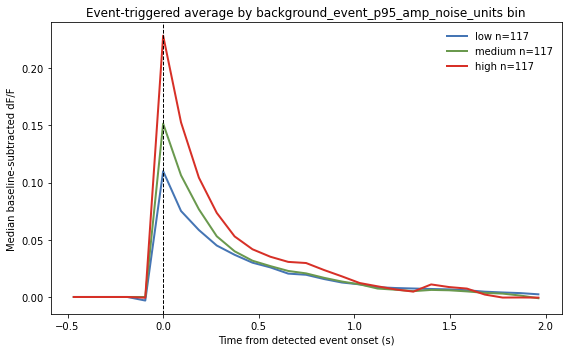

In [24]:
def event_triggered_average_for_rois(dff, events, timestamps, roi_indices, event_threshold=0.0, pre_s=0.5, post_s=2.0, max_events_per_roi=100):
    frame_rate = 1 / np.nanmedian(np.diff(timestamps))
    pre = max(1, int(round(pre_s * frame_rate)))
    post = max(2, int(round(post_s * frame_rate)))
    windows = []
    for roi in roi_indices:
        onsets = _event_onsets(events[:, int(roi)], event_threshold)
        valid = onsets[(onsets >= pre) & (onsets + post < dff.shape[0])]
        if len(valid) > max_events_per_roi:
            valid = valid[np.linspace(0, len(valid) - 1, max_events_per_roi).astype(int)]
        for onset in valid:
            win = dff[onset-pre:onset+post+1, int(roi)].astype(float)
            win = win - np.nanmedian(win[:pre])
            windows.append(win)
    if not windows:
        return None, None
    t = np.arange(-pre, post + 1) / frame_rate
    return t, np.nanmedian(np.stack(windows), axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
for bin_name in ["low", "medium", "high"]:
    rows = plane_df.loc[plane_df["metric_bin"] == bin_name]
    t, avg = event_triggered_average_for_rois(
        dff,
        events,
        timestamps,
        rows.roi_index.to_numpy(),
        event_threshold=EVENT_THRESHOLD,
        pre_s=BACKGROUND_EXCLUDE_PRE_S,
        post_s=BACKGROUND_EXCLUDE_POST_S,
    )
    if avg is not None:
        ax.plot(t, avg, label=f"{bin_name} n={len(rows)}", color=colors[bin_name], lw=2)
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("Time from detected event onset (s)")
ax.set_ylabel("Median baseline-subtracted dF/F")
ax.set_title(f"Event-triggered average by {METRIC_FOR_TRACE_BINS} bin")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Retrieve an individual ROI trace from the saved table

Use this helper when you find a high/low/disagreement ROI in the compact metrics table and want to inspect the underlying trace without storing all traces in the summary CSV.

In [23]:
def retrieve_cached_roi_trace(metrics_table, row_index, max_frames=None):
    row = metrics_table.iloc[int(row_index)]
    session_dir = Path(row.session_dir)
    plane = row.plane
    roi_index = int(row.roi_index)
    dff, events, timestamps = load_cached_plane(session_dir, plane, max_frames=max_frames)
    return {
        "session_dir": session_dir,
        "plane": plane,
        "roi_index": roi_index,
        "timestamps": timestamps,
        "dff": dff[:, roi_index],
        "events": None if events is None else events[:, roi_index],
        "metrics": row,
    }

example = retrieve_cached_roi_trace(roi_metrics.sort_values("background_event_p95_amp_noise_units", ascending=False), 0, max_frames=MAX_FRAMES)
print(example["plane"], example["roi_index"])

VISl_5 189
